In [1]:
!pip install torchsummary scikit-learn

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import timm
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, roc_curve, auc, f1_score
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from torchsummary import summary
import time
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR




# Check available GPUs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {torch.cuda.device_count()} GPUs")

Using 2 GPUs


In [2]:
# Set a random seed for reproducibility
random_seed = 42
torch.manual_seed(random_seed)


# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,
    contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Custom dataset class to handle images safely
class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            image = Image.open(path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, target
        except Exception as e:
            print(f"Error loading image at {path}: {e}")
            return torch.zeros((3, 224, 224)), target

# Load dataset
data_dir = '/kaggle/input/diabetic-augmented/Augmented data set'
dataset = SafeImageFolder(root=data_dir, transform=transform)

# Ensure consistent dataset splitting
train_size = int(0.80 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(random_seed)  # Use the random seed
)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load Beit Transformer model
model = timm.create_model('vitamin_base_224', pretrained=True, num_classes=1)
model = model.to(device)

# Print model summary
summary(model, (3, 224, 224))

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
#optimizer = Adam(model.parameters(), lr=0.00005)

# Lists to store metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
epoch_times = []


# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=15)




# Early stopping parameters
patience = 15
best_val_loss = float('inf')
early_stop_counter = 0

# Initialize total training time
total_train_time = 0

# Training and validation loop
epochs = 30
for epoch in range(epochs):
    start_epoch_time = time.time()
    
    # Training phase
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    train_accuracy = accuracy_score(train_labels, train_preds)
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_accuracy)
    
    # Validation phase
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_accuracy = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)
    
    # Epoch summary
    epoch_time = time.time() - start_epoch_time
    epoch_times.append(epoch_time)
    total_train_time += epoch_time
    
    print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, "
          f"Train Acc: {train_accuracy:.4f}, Val Loss: {val_losses[-1]:.4f}, "
          f"Val Acc: {val_accuracy:.4f}, Epoch Time: {epoch_time:.2f} seconds")
    
    # Early stopping and save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        early_stop_counter = 0
        print("Validation loss improved. Saving model...")
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
    else:
        early_stop_counter += 1
        print(f"No improvement in validation loss for {early_stop_counter} epoch(s).")
        if early_stop_counter >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Print total training time
print(f"\nTotal training time: {total_train_time:.2f} seconds ({total_train_time / 60:.2f} minutes)")
print(f"Average training time per epoch: {total_train_time / len(epoch_times):.2f} seconds")

pytorch_model.bin:   0%|          | 0.00/846M [00:00<?, ?B/s]

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 128, 112, 112]           3,584
          Identity-2        [-1, 128, 112, 112]               0
              GELU-3        [-1, 128, 112, 112]               0
    LayerNormAct2d-4        [-1, 128, 112, 112]             256
            Conv2d-5        [-1, 128, 112, 112]         147,584
              Stem-6        [-1, 128, 112, 112]               0
         AvgPool2d-7          [-1, 128, 56, 56]               0
          Identity-8          [-1, 128, 56, 56]               0
      Downsample2d-9          [-1, 128, 56, 56]               0
         Identity-10        [-1, 128, 112, 112]               0
         Identity-11        [-1, 128, 112, 112]               0
   LayerNormAct2d-12        [-1, 128, 112, 112]             256
         Identity-13        [-1, 128, 112, 112]               0
           Conv2d-14        [-1, 512, 1

Epoch 1/30 - Validation: 100%|██████████| 123/123 [01:05<00:00,  1.89it/s]


Epoch [1/30], Train Loss: 0.1174, Train Acc: 0.9595, Val Loss: 0.1144, Val Acc: 0.9592, Epoch Time: 916.49 seconds
Validation loss improved. Saving model...


Epoch 2/30 - Validation: 100%|██████████| 123/123 [00:52<00:00,  2.32it/s]


...

Epoch [28/30], Train Loss: 0.0102, Train Acc: 0.9969, Val Loss: 0.0392, Val Acc: 0.9837, Epoch Time: 856.87 seconds
No improvement in validation loss for 1 epoch(s).


Epoch 29/30 - Validation: 100%|██████████| 123/123 [00:54<00:00,  2.26it/s]


Epoch [29/30], Train Loss: 0.0087, Train Acc: 0.9974, Val Loss: 0.0269, Val Acc: 0.9918, Epoch Time: 858.41 seconds
No improvement in validation loss for 2 epoch(s).


Epoch 30/30 - Validation: 100%|██████████| 123/123 [00:52<00:00,  2.33it/s]

Epoch [30/30], Train Loss: 0.0086, Train Acc: 0.9973, Val Loss: 0.0401, Val Acc: 0.9872, Epoch Time: 856.24 seconds
No improvement in validation loss for 3 epoch(s).

Total training time: 25715.26 seconds (428.59 minutes)
Average training time per epoch: 857.18 seconds


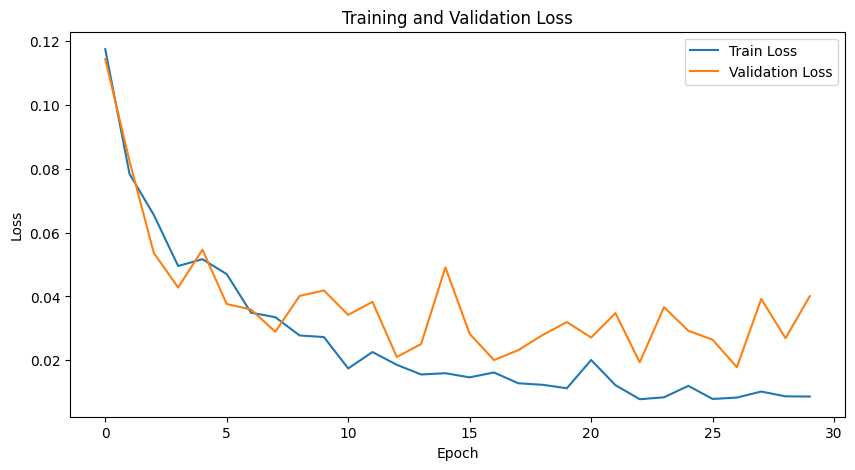

Training and validation loss graph saved to: /kaggle/working/train_val_loss.png


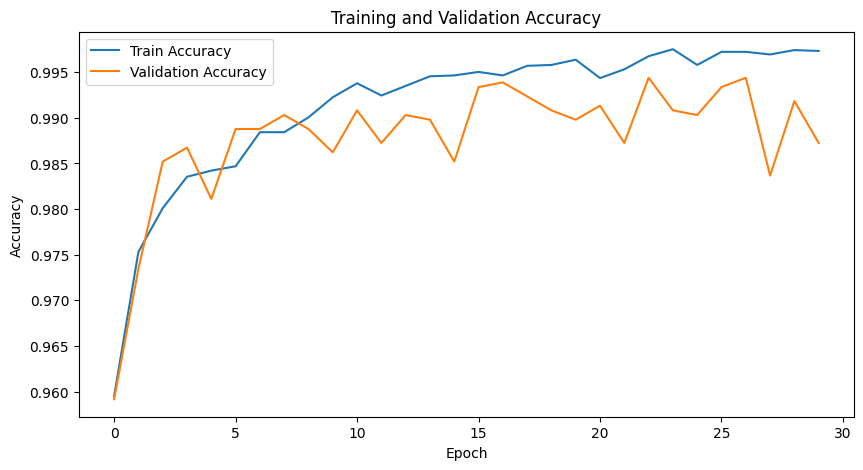

Training and validation accuracy graph saved to: /kaggle/working/train_val_accuracy.png

Evaluating on the test set...


100%|██████████| 41/41 [00:21<00:00,  1.90it/s]



Test Set Results:
Total images: 654
Correct predictions: 643
Accuracy: 0.9832


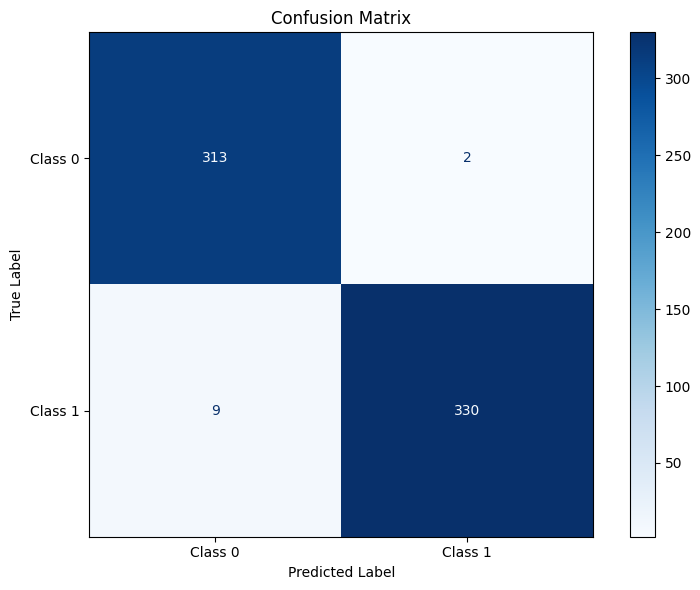

Confusion matrix image saved to: /kaggle/working/confusion_matrix.png
F1 Score: 0.9836


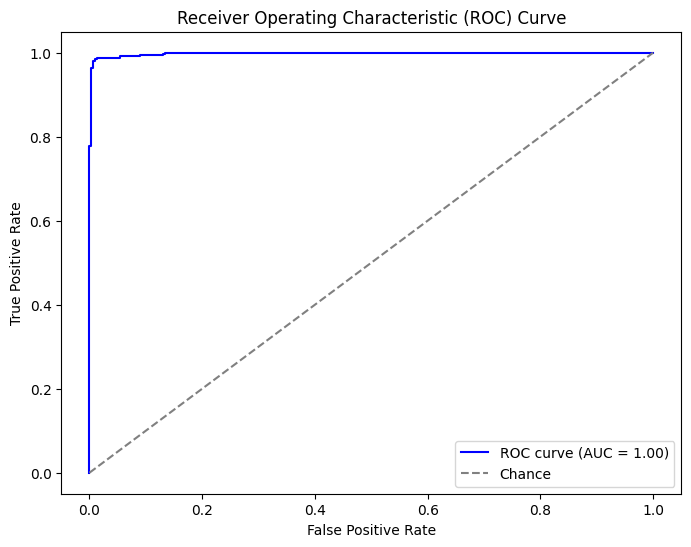

ROC curve image saved to: /kaggle/working/roc_curve.png


In [3]:
# Plotting and saving training/validation loss graph
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
loss_graph_path = '/kaggle/working/train_val_loss.png'
plt.savefig(loss_graph_path)
plt.show()
print(f"Training and validation loss graph saved to: {loss_graph_path}")

# Plotting and saving training/validation accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
accuracy_graph_path = '/kaggle/working/train_val_accuracy.png'
plt.savefig(accuracy_graph_path)
plt.show()
print(f"Training and validation accuracy graph saved to: {accuracy_graph_path}")

# Evaluate the model on the test set
model.eval()
test_preds, test_labels, test_probs = [], [], []  # Added test_probs to store probabilities

print("\nEvaluating on the test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs)  # Get probabilities
        preds = (probs > 0.5).int()  # Convert probabilities to binary predictions
        
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())  # Store probabilities for ROC and AUC

# Flatten predictions, labels, and probabilities
test_preds = [p[0] for p in test_preds]
test_labels = [l[0] for l in test_labels]
test_probs = [p[0] for p in test_probs]  # Ensure test_probs is a flat list

# Count total test images and correct predictions
total_test_images = len(test_labels)
correct_predictions = sum([1 for true, pred in zip(test_labels, test_preds) if true == pred])
accuracy = correct_predictions / total_test_images

print(f"\nTest Set Results:")
print(f"Total images: {total_test_images}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_preds)

# Visualize Confusion Matrix with Enhanced Design
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
confusion_matrix_path = '/kaggle/working/confusion_matrix.png'
plt.savefig(confusion_matrix_path)
plt.show()
print(f"Confusion matrix image saved to: {confusion_matrix_path}")

# F1 Score
f1 = f1_score(test_labels, test_preds)
print(f"F1 Score: {f1:.4f}")

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(test_labels, test_probs)  # Use test_probs for ROC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
roc_curve_path = '/kaggle/working/roc_curve.png'
plt.savefig(roc_curve_path)
plt.show()
print(f"ROC curve image saved to: {roc_curve_path}")

Using device: cuda


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Generating LIME visualization...


  0%|          | 0/1000 [00:00<?, ?it/s]

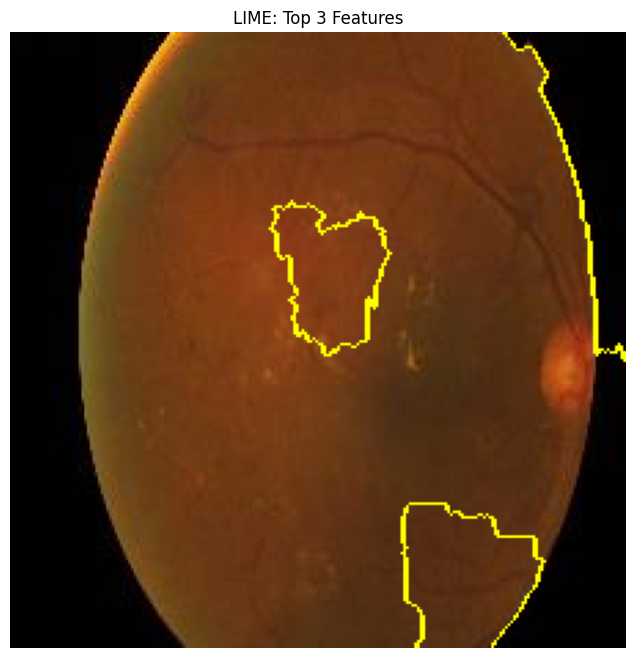

Generating SHAP visualization...


unrecognized nn.Module: LayerNorm
unrecognized nn.Module: Identity
unrecognized nn.Module: GELU
unrecognized nn.Module: LayerNorm2d


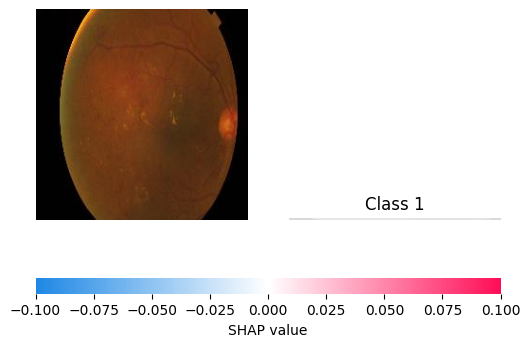

<Figure size 640x480 with 0 Axes>

In [4]:
from skimage import io
import torchvision.transforms as transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
import matplotlib.pyplot as plt
import torch

# Define constants
MODEL_PATH = "/kaggle/working/best_model.pth"  # Path to your saved model
IMAGE_PATH = "/kaggle/input/diabetic-small-set/smalltest/nd/000c1434d8d7_png.rf.620970d7d209700b4cf09b8f36f52ff9.jpg"  # Path to your test image
IMAGE_SIZE = 224  # Input size of your model

# Step 1: Check if CUDA is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 2: Load the model
def load_model():
    model = timm.create_model('vitamin_base_224', pretrained=False, num_classes=1)
    state_dict = torch.load(MODEL_PATH, map_location=device)  # Load model to the device
    model.load_state_dict(state_dict)
    model = model.to(device)  # Ensure the model is on the right device
    model.eval()
    return model

# Step 3: Preprocess the image
def preprocess_image(img_path, image_size=224):
    img = io.imread(img_path)  # Read the image
    img = img[:, :, :3]  # Ensure 3 channels
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert to tensor
        transforms.Resize((image_size, image_size)),  # Resize to model input size
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # Normalize
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension and move to device (GPU/CPU)
    return img, img_tensor

# Step 4: Define the LIME visualization
def lime_visualization(model, org_img, img_tensor):
    # Define a prediction function
    def predict_function(images):
        images = torch.tensor(images).permute(0, 3, 1, 2)  # Convert to [B, C, H, W]
        images = images.float() / 255.0  # Normalize to match input range
        images = images.to(device)  # Move to GPU/CPU as needed
        with torch.no_grad():
            preds = model(images).cpu().numpy()
        return preds

    # Initialize LIME explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the image
    explanation = explainer.explain_instance(
        org_img,  # Original image (HxWxC)
        predict_function,  # Prediction function
        top_labels=1,  # Explain top label
        hide_color=0,
        num_samples=1000,
    )

    # Get explanation for the top label
    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],  # Top predicted label
        positive_only=True,
        num_features=3,  # Top 3 features
        hide_rest=False,
    )

    # Show and save LIME result
    plt.figure(figsize=(8, 8))
    plt.imshow(mark_boundaries(temp / 255.0, mask))  # Overlay boundaries on the image
    plt.title("LIME: Top 3 Features")
    plt.axis("off")
    plt.savefig("/kaggle/working/lime_visualization.png", format="png")  # Save as PNG
    plt.show()

# Step 5: Define the SHAP visualization
def shap_visualization(model, img_tensor, org_img):
    # Initialize SHAP explainer
    explainer = shap.DeepExplainer(model, img_tensor.to(device))  # Move the image tensor to GPU/CPU

    # Explain the prediction for the input image
    shap_values = explainer.shap_values(img_tensor.to(device))  # Input image tensor

    # Visualize SHAP values for the single class
    shap.image_plot(
        shap_values=shap_values,
        pixel_values=org_img[np.newaxis, ...],  # Original image in numpy format
        labels=["Class 1"]
    )
    plt.savefig("/kaggle/working/shap_visualization.png", format="png")  # Save as PNG

# Main execution
if __name__ == "__main__":
    # Load model
    model = load_model()

    # Preprocess the image
    org_img, img_tensor = preprocess_image(IMAGE_PATH, IMAGE_SIZE)

    # Visualize using LIME
    print("Generating LIME visualization...")
    lime_visualization(model, org_img, img_tensor)

    # Visualize using SHAP
    print("Generating SHAP visualization...")
    shap_visualization(model, img_tensor, org_img)


Using device: cuda


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Generating and saving SHAP visualization...
Model Output (before softmax): tensor([[-12.0482]], device='cuda:0')
Model Output (after softmax): tensor([[1.]], device='cuda:0')
SHAP Values: [[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]]]


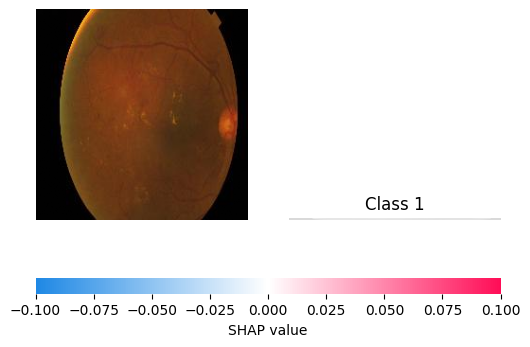

SHAP visualization saved to /kaggle/working/shap_visualization.png


In [5]:
import torch
import timm
import shap
import torch.nn.functional as F
import numpy as np
from skimage import io
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Define constants
MODEL_PATH = "/kaggle/working/best_model.pth"
IMAGE_PATH = "/kaggle/input/diabetic-small-set/smalltest/nd/000c1434d8d7_png.rf.620970d7d209700b4cf09b8f36f52ff9.jpg"
IMAGE_SIZE = 224

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model function
def load_model():
    model = timm.create_model('vitamin_base_224', pretrained=False, num_classes=1)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

# Preprocess image function
def preprocess_image(img_path, image_size=224):
    img = io.imread(img_path)[:, :, :3]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((image_size, image_size)),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img, img_tensor

# SHAP visualization function
def shap_visualization(model, img_tensor, org_img, output_dir="/kaggle/working/"):
    model = model.to(device)
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        model_output = model(img_tensor)
        print("Model Output (before softmax):", model_output)
        model_output = F.softmax(model_output, dim=1)  # Apply softmax to get probabilities
        print("Model Output (after softmax):", model_output)

    explainer = shap.DeepExplainer(model, img_tensor)
    shap_values = explainer.shap_values(img_tensor)

    org_img = org_img / 255.0  # Normalize image to [0, 1]
    print(f"SHAP Values: {shap_values}")

    shap_plot = shap.image_plot(
        shap_values=shap_values,
        pixel_values=org_img[np.newaxis, ...],
        labels=["Class 1"]
    )

    shap_output_path = f"{output_dir}shap_visualization.png"
    plt.savefig(shap_output_path)
    plt.close()
    print(f"SHAP visualization saved to {shap_output_path}")

# Main execution
if __name__ == "__main__":
    model = load_model()
    org_img, img_tensor = preprocess_image(IMAGE_PATH, IMAGE_SIZE)
    
    print("Generating and saving SHAP visualization...")
    shap_visualization(model, img_tensor, org_img)


In [6]:
from imageio import imread  # Correct import for imread
import numpy as np
import torch
from torch import nn
import albumentations as A
from skimage import io  # For `imshow`

A new version of Albumentations is available: 1.4.21 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.


In [7]:
img_path='/kaggle/input/diabetic-small-set/smalltest/nd/000c1434d8d7_png.rf.620970d7d209700b4cf09b8f36f52ff9.jpg'
model_path='/kaggle/working/best_model.pth'
image_size= 224

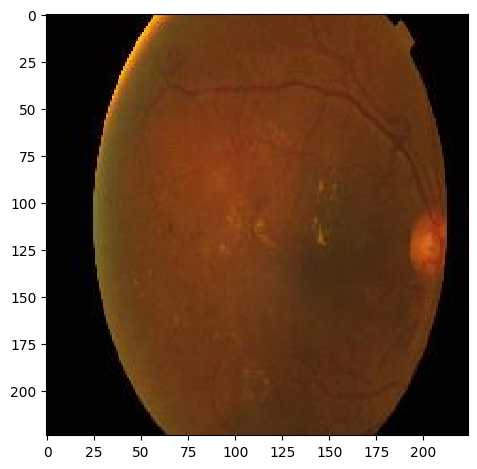

In [8]:
def get_image(im_path, shape=image_size):
    img = io.imread(im_path) [:,:, :3] ## HXWXC
    org_img = img.copy()
    img = A.Normalize()(image=img) ["image"] ## HxWxC
    norm_img = img.copy()
    img = np.transpose(img, (2,0,1)) ## CxHxW
    img = np.expand_dims(img, 0) ## B=1, CxHxW
    img = torch.tensor(img)
    img = nn. Upsample ((shape, shape), mode='bilinear')(img)
    return img, norm_img, org_img


img, norm_img, org_img = get_image(img_path)
io.imshow(org_img)

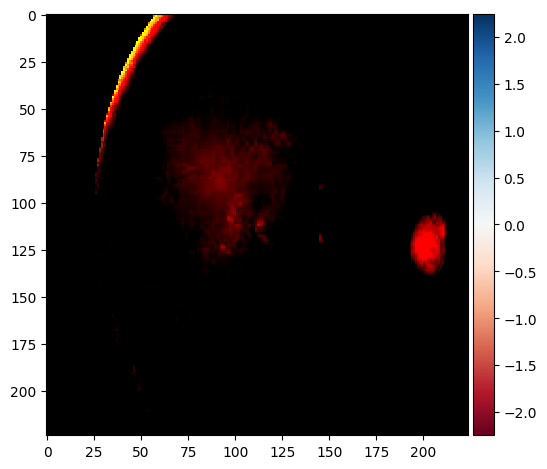

In [9]:
io.imshow(norm_img)

In [10]:
model.blocks[-1].attn

Attention(
  (qkv): Linear(in_features=768, out_features=2304, bias=True)
  (q_norm): Identity()
  (k_norm): Identity()
  (attn_drop): Dropout(p=0.0, inplace=False)
  (proj): Linear(in_features=768, out_features=768, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)

In [11]:
model=model.cuda()

In [12]:
outputs = {}
def get_outputs(name: str):
    def hook (model, input, output):
        outputs[name] = output.detach()

    return hook


model.blocks[-1].attn.q_norm.register_forward_hook(get_outputs('Q'))
model.blocks[-1].attn.k_norm.register_forward_hook(get_outputs('K'))
model.blocks [-1].register_forward_hook(get_outputs('features'))
model(img.cuda())

tensor([[-12.0482]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [13]:
scale = model.blocks [-1].attn.scale

outputs["attention"] = (outputs["Q"]@ outputs["K"].transpose(-2, -1))*scale
outputs["attention"] = outputs ["attention"].softmax(dim=-1)

outputs["attention"].shape

torch.Size([1, 12, 196, 196])

In [14]:
b, num_heads, num_patches_1, num_patches_1 = outputs ["attention"].shape
map_size = int(np.sqrt(num_patches_1-1))
for attention_head in range(num_heads):
    attention_map = outputs ["attention"] [:, attention_head,0,1:] ## 1,4096
'''
    attention_map = attention_map.view(1,1, map_size, map_size)
    attention_map = nn. Upsample(size=(image_size, image_size)) (attention_map)
    attention_map = attention_map[0,0,:,:]. detach().cpu().numpy()
    io.imshow(attention_map)
    plt.show()
'''

'\n    attention_map = attention_map.view(1,1, map_size, map_size)\n    attention_map = nn. Upsample(size=(image_size, image_size)) (attention_map)\n    attention_map = attention_map[0,0,:,:]. detach().cpu().numpy()\n    io.imshow(attention_map)\n    plt.show()\n'

In [15]:
num_spatial_patches = outputs["attention"].shape[-1] - 1

For vitamin, chat gpt suggested solution 1:

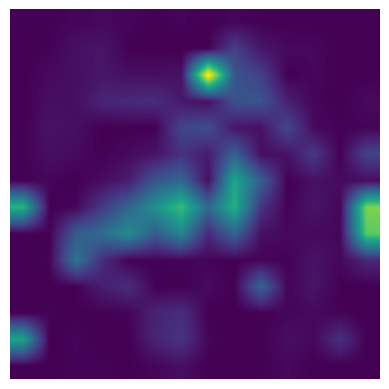

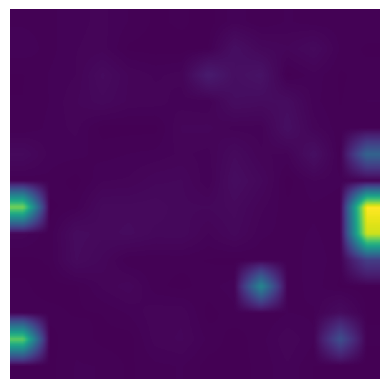

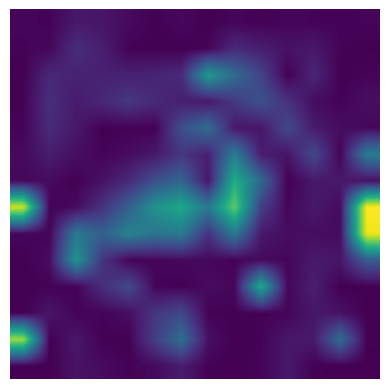

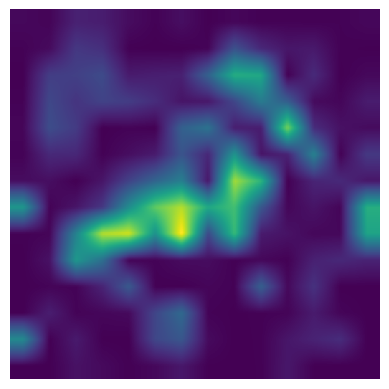

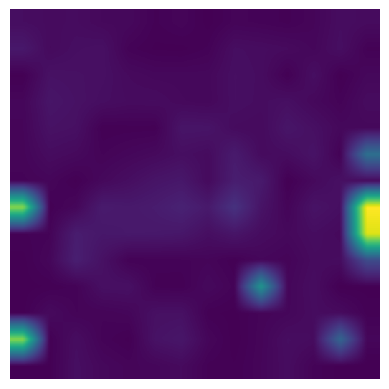

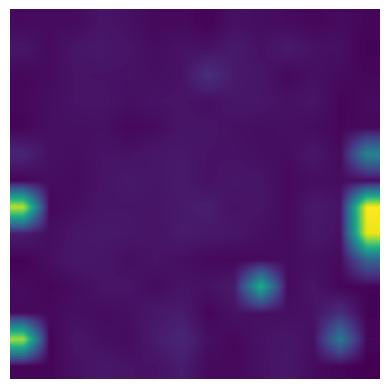

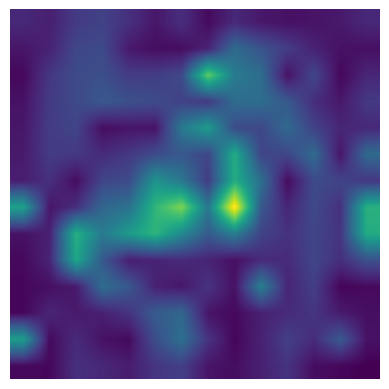

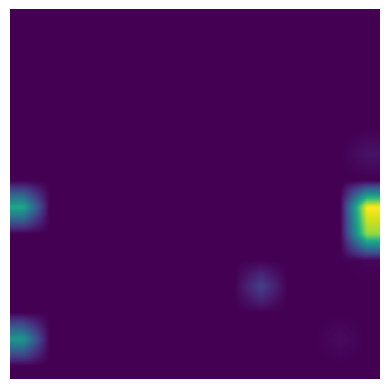

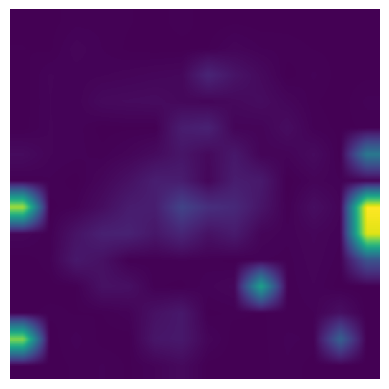

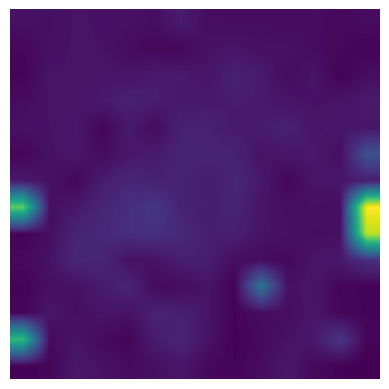

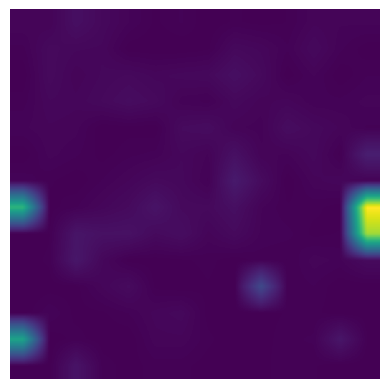

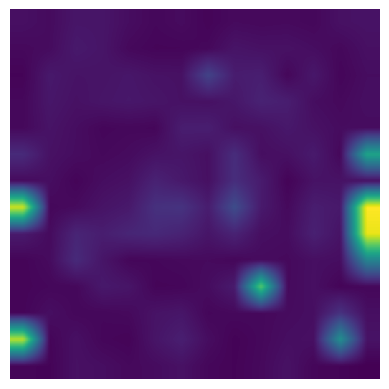

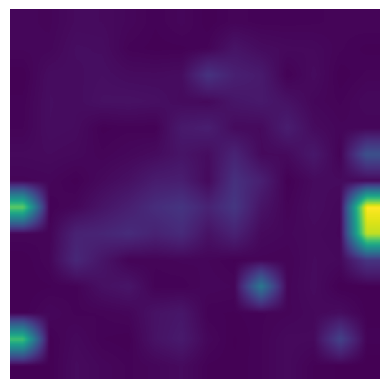

In [16]:
import os
import numpy as np
import torch
from torch import nn
from skimage import io
import matplotlib.pyplot as plt

# Create a directory to save attention maps
output_dir = "attention_map"
os.makedirs(output_dir, exist_ok=True)

# For individual attention maps
for attention_head in range(num_heads):
    # Extract attention map (excluding the class token)
    attention_map = outputs["attention"][:, attention_head, 0, 1:]  # Shape: [1, num_spatial_patches]
    
    # Pad to the nearest square number
    target_size = int(np.ceil(np.sqrt(num_spatial_patches)) ** 2)
    padding = target_size - num_spatial_patches
    attention_map = torch.cat([attention_map, torch.zeros((1, padding), device=attention_map.device)], dim=1)

    # Compute new map_size
    map_size = int(np.sqrt(target_size))

    # Reshape into [1, 1, map_size, map_size]
    attention_map = attention_map.view(1, 1, map_size, map_size)

    # Interpolate to (image_size, image_size)
    attention_map = nn.Upsample(size=(image_size, image_size), mode="bilinear", align_corners=False)(attention_map)

    # Extract the single channel and convert to numpy for visualization
    attention_map = attention_map[0, 0, :, :].detach().cpu().numpy()

    # Show the attention map
    plt.imshow(attention_map, cmap="viridis")
    plt.axis("off")
    plt.show()

    # Save the attention map
    plt.imsave(f"{output_dir}/attention_head_{attention_head}.png", attention_map, cmap="viridis")

# For aggregated attention map
# Sum or average attention maps from all heads
attention_map = outputs["attention"][:, :, 0, 1:].mean(dim=1)  # Shape: [1, num_spatial_patches]

# Proceed with processing as before
num_spatial_patches = attention_map.shape[-1]
target_size = int(np.ceil(np.sqrt(num_spatial_patches)) ** 2)
padding = target_size - num_spatial_patches
attention_map = torch.cat([attention_map, torch.zeros((1, padding), device=attention_map.device)], dim=1)

map_size = int(np.sqrt(target_size))
attention_map = attention_map.view(1, 1, map_size, map_size)
attention_map = nn.Upsample(size=(image_size, image_size), mode="bilinear", align_corners=False)(attention_map)
attention_map = attention_map[0, 0, :, :].detach().cpu().numpy()

# Show the aggregated attention map
plt.imshow(attention_map, cmap="viridis")
plt.axis("off")
plt.show()

# Save the aggregated attention map
plt.imsave(f"{output_dir}/aggregation_all_images.png", attention_map, cmap="viridis")
